# PICKO · Notebook 2 — Tool Families, Finetuning & the Research Story

Explore the scientific tool families, finetune Needle (or reuse a checkpoint), and measure
**two things separately**:
- **Tool-function selection** — did PICKO pick the right *tool*?  (`selection_acc`, `name_f1`)
- **Parameter extraction** — given the right tool, did it extract the right *arguments*?  (`args_exact_acc`, `param_f1`)

Then tell the story across the three research dimensions:
- **D2** parameter extraction · **D3** disambiguation of similar tools · **D1** tool-set size.

> Kernel: **PICKO (.venv)**. Finetuning is **reuse-on-demand** — an existing checkpoint is loaded
> automatically; set `RUN_FINETUNE=True` to retrain (~40 min on CPU).

### 1 · Setup

In [1]:
import os, sys, json, glob, subprocess
ROOT = os.path.abspath("..")
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
try:
    import seaborn as sns; sns.set_theme(style="whitegrid")
except Exception:
    sns = None
from scripts.tool_catalog import Catalog, family_of
cat = Catalog()
print(f"Catalog: {len(cat.tools)} tools · {len(cat.list_families())} families")

Catalog: 75 tools · 11 families


## 2 · Explore the tool families

The catalog (`full_tools_53tools_11products.json`) holds **75 tools in 11 families/products**,
grouped into **4 categories** (via `tools_metadata.csv`). Parameter counts vary widely — that
variation is what stresses **D2** (parameter extraction).

n_tools  avg_params
category                     family                               
Academic & Literature Search arxiv                  14         2.1
                             pubmed                  4         2.5
                             semantic_scholar        5         1.8
                             unpaywall               1         1.0
Data & ML Repositories       github                  7         5.0
                             hf                     12         3.3
                             kaggle                 11         3.1
General Knowledge & Web      google                  2         3.5
                             wikipedia              10         1.7
Scholarly Metadata           crossref                4         1.8
                             openalex                5         4.8

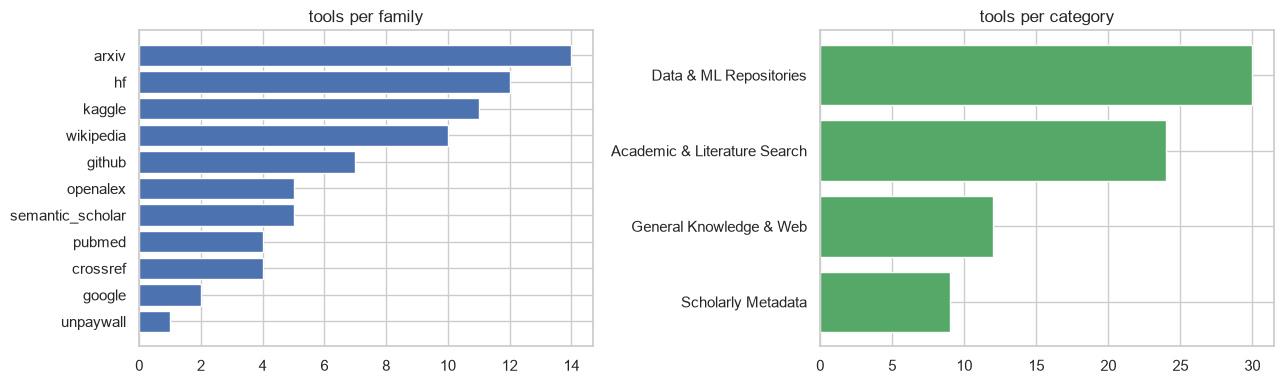

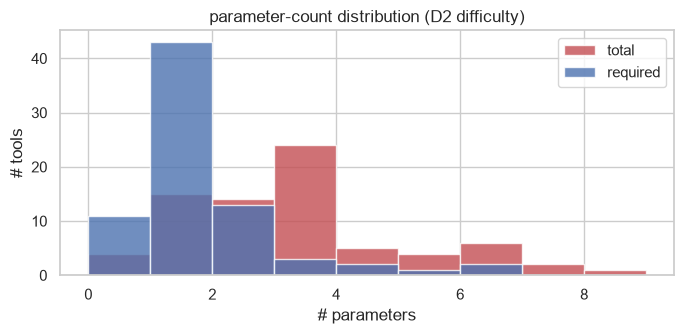

In [2]:
df = cat.as_dataframe()
display(df.groupby(["category","family"]).agg(n_tools=("tool","size"),
        avg_params=("total_params","mean")).round(1))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
fam = cat.list_families()
ax[0].barh(list(fam)[::-1], [fam[f]["count"] for f in fam][::-1], color="#4C72B0")
ax[0].set_title("tools per family")
catcount = df.groupby("category")["tool"].size().sort_values()
ax[1].barh(catcount.index, catcount.values, color="#55A868")
ax[1].set_title("tools per category"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3.5))
plt.hist(df["total_params"], bins=range(0, df.total_params.max()+2), color="#C44E52", alpha=.8, label="total")
plt.hist(df["required_params"], bins=range(0, df.total_params.max()+2), color="#4C72B0", alpha=.8, label="required")
plt.xlabel("# parameters"); plt.ylabel("# tools"); plt.legend(); plt.title("parameter-count distribution (D2 difficulty)")
plt.tight_layout(); plt.show()

## 3 · Choose what to analyze

`DATA_SOURCE` is the full balanced pool from Notebook 1 (**75 tools × 120 + negatives**). You then
**pick a tool subset** (3a) and the dataset is **re-scoped** to it (3b): only rows whose gold tool is
in the subset are kept, and each example is rewritten to offer **only the subset's tools**.

> Why re-scope? The generated `tools` field carries the gold tool **plus random distractors drawn
> from all 75 tools**. To study a specific subset cleanly (D3 disambiguation, D1 tool-set size), every
> example must offer exactly the tools under study — otherwise we'd train/evaluate over a different set.

In [19]:
DATA_SOURCE = os.path.join(ROOT, "data", "picko_balanced.jsonl")  # 75 tools x 120 + negatives (from Notebook 1)
CKPT_GLOB  = os.path.join(ROOT, "checkpoints", "needle_finetuned_*_best.pkl")
RUN_FINETUNE = True          # flip to True to retrain on the scoped subset (~40 min CPU)
EPOCHS, BATCH = 1, 32
EVAL_SUBSAMPLE = None         # e.g. 40 to speed up the D1 sweep on CPU; None = full test set

raw = [json.loads(l) for l in open(DATA_SOURCE) if l.strip()]
all_tools = sorted({a['name'] for e in raw for a in json.loads(e['answers']) if a.get('name')})
print(f"{len(raw)} raw examples · {len(all_tools)} distinct gold tools in {os.path.basename(DATA_SOURCE)}")

9120 raw examples · 75 distinct gold tools in picko_balanced.jsonl


### 3a · Pick the tool subset (baseline)

Paste the tools you want to study into `SUBSET` (any names from the 75-tool catalog). The default is
the **11-per-family set** — one representative tool per source — which is maximally confusable and
makes the cleanest D3 story. All names are validated against the catalog.

In [20]:
# Default subset = one tool per family . Override with your own list, e.g.:
#   SUBSET = ["arxiv_search_papers", "pubmed_search_articles", "semantic_scholar_search_papers"]
SUBSET = [t["name"] for t in cat.select_tools(one_per_family=True)[0]][3:8]

unknown = [n for n in SUBSET if n not in cat.by_name]
assert not unknown, f"Not in catalog: {unknown}"
assert len(SUBSET) >= 2, "Pick at least 2 tools."

sub_df = cat.as_dataframe()
sub_df = sub_df[sub_df["tool"].isin(SUBSET)][["tool","family","category","required_params","total_params"]]
print(f"SUBSET: {len(SUBSET)} tools")
display(sub_df.reset_index(drop=True))

SUBSET: 5 tools


,tool,family,category,required_params,total_params
0,pubmed_search_articles,pubmed,Academic & Literature Search,1,3
1,arxiv_search_papers,arxiv,Academic & Literature Search,1,6
2,wikipedia_search_wikipedia,wikipedia,General Knowledge & Web,1,2
3,semantic_scholar_search_papers,semantic_scholar,Academic & Literature Search,1,3
4,google_web_search,google,General Knowledge & Web,1,4


### 3b · Re-scope the dataset to `SUBSET`

Keep only rows whose gold tool is in `SUBSET`, rewrite each `tools` field to offer **only** the subset
tools (all of them when ≤ 12, else gold + sampled subset distractors), and write a scoped JSONL that
the rest of the notebook trains and evaluates on. The prints are the alignment check.

In [21]:
from needle.training.finetune import _per_tool_split

scoped = cat.restrict_dataset(raw, SUBSET, seed=0)
TAG = f"{len(SUBSET)}tools"
DATA_JSONL = os.path.join(ROOT, "data", f"picko_subset_{TAG}.jsonl")
with open(DATA_JSONL, "w") as f:
    for e in scoped:
        f.write(json.dumps(e, ensure_ascii=False) + "\n")

# ---- alignment check ----
examples = scoped
sset = set(SUBSET)
offer_ok = all({t["name"] for t in json.loads(e["tools"])} <= sset for e in examples)
gold_ok, negatives, gold_counts = True, 0, {}
for e in examples:
    ans = json.loads(e["answers"])
    g = next((c["name"] for c in ans if isinstance(c, dict) and c.get("name")), None)
    if g is None:
        negatives += 1
    else:
        gold_counts[g] = gold_counts.get(g, 0) + 1
        if g not in sset: gold_ok = False

train, val, test = _per_tool_split(examples)
print(f"scoped -> {DATA_JSONL}")
print(f"{len(examples)} examples ({negatives} negatives) · offered ⊆ SUBSET: {offer_ok} · gold ∈ SUBSET: {gold_ok}")
print(f"split: train {len(train)} / val {len(val)} / test {len(test)}")
display(pd.Series(gold_counts).sort_index().rename("positives/tool").to_frame())

scoped -> /Users/hdrbytn/Documents/Huji/master/llm-for-sceince/picko/data/picko_subset_5tools.jsonl
720 examples (120 negatives) · offered ⊆ SUBSET: True · gold ∈ SUBSET: True
split: train 600 / val 60 / test 60


,positives/tool
arxiv_search_papers,120
google_web_search,120
pubmed_search_articles,120
semantic_scholar_search_papers,120
wikipedia_search_wikipedia,120


### 4 · Finetune (reuse-on-demand)

In [22]:
if RUN_FINETUNE:
    print(f"Finetuning on {os.path.basename(DATA_JSONL)} … (slow on CPU)")
    subprocess.run(["needle","finetune",DATA_JSONL,"--epochs",str(EPOCHS),"--batch-size",str(BATCH)],
                   cwd=ROOT, check=True)
ckpts = sorted(glob.glob(CKPT_GLOB), key=os.path.getmtime)
assert ckpts, "No finetuned checkpoint found — set RUN_FINETUNE=True to train on this SUBSET."
CKPT = ckpts[-1]
print("Using checkpoint:", os.path.basename(CKPT))

# Freshness guard: a checkpoint older than the scoped data was trained on a different
# tool set, so its results won't align with the current SUBSET.
if os.path.getmtime(CKPT) < os.path.getmtime(DATA_JSONL):
    print("\n⚠️  This checkpoint is OLDER than the scoped dataset — it was trained on a different\n"
          "    tool set. Set RUN_FINETUNE=True and re-run this cell to retrain on the current SUBSET.")

Finetuning on picko_subset_5tools.jsonl … (slow on CPU)
Loaded 720 examples from /Users/hdrbytn/Documents/Huji/master/llm-for-sceince/picko/data/picko_subset_5tools.jsonl
Split: 600 train / 60 val / 60 test (per-tool)
  Compacting JSON and preparing texts...


Tokenizing tools (contrastive):   0%|          | 0/120 [00:00<?, ?it/s]

Prepared 600 tool-call pairs


  Compacting answers:   0%|          | 0/60 [00:00<?, ?it/s]

  Contrastive: 600 queries, 3000 individual tools
  Packed 600 sequences into 600 bins (49% utilization)
  Compacting JSON and preparing texts...


...

Prepared 60 tool-call pairs


Writing packed bins: 100%|██████████| 60/60 [00:00<00:00, 350987.78it/s]


  Contrastive: 60 queries, 300 individual tools
  Packed 60 sequences into 60 bins (49% utilization)
Tokenized: 600 train / 60 val sequences
Evaluating base model on 60 test examples...
BASE_EVAL:{"call_f1": 0.303, "name_f1": 0.9091, "exact_match": 0.3, "parse_rate": 1.0, "args_acc": 0.3333, "n": 50, "per_tool": {"pubmed_search_articles": {"correct": 3, "total": 10}, "arxiv_search_papers": {"correct": 2, "total": 10}, "wikipedia_search_wikipedia": {"correct": 4, "total": 10}, "google_web_search": {"correct": 3, "total": 10}, "semantic_scholar_search_papers": {"correct": 3, "total": 10}}}
  Base: call_f1=30.3%, exact=30.0%
Starting training...

[1/3] Detecting devices...
      1 local device(s), 1 total across 1 hosts

[2/3] Loading tokenizer...

[3/3] Loading prepared data from disk (mmap)...
      600 train / 60 val packed bins (memory-mapped)
      Contrastive: 600 queries, 3,000 tools
Resuming from checkpoint: /Users/hdrbytn/Documents/Huji/master/llm-for-sceince/picko/checkpoints/ne

Epoch 1/1: 100%|██████████| 18/18 [23:58<00:00, 79.90s/it, text_loss=0.1872, text_ppl=1.09]


  ** New best single call_f1=44.4% → checkpoints/needle_finetuned_20260911003724_8110_12_512_best.pkl
[hf] Warning: checkpoint upload failed: (Request ID: Root=1-6aa32bec-037518f717a74fc448fbf87a;c6b6f45d-478b-4bc9-b44a-d9271a38d5cb)

403 Forbidden: You don't have the rights to create a model under the namespace "Cactus-Compute".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

  ─────────────────────────────────────
  Epoch 1/1
  ─────────────────────────────────────
  Text loss            0.1872
  Text val ppl           1.09
  Quant val ppl          1.09  (INT4)
  ─── Single-Call (50 samples) ──
  JSON parse         100.0%
  Name F1             94.9%
  Param haluc          0.0%
  Param miss           9.9%
  Value acc           78.0%
  Args acc            46.8%
  Call F1             44.4%
  Exact match         44.0%
  #tools     n   name_f1   nTP  nFP  nFN   call_f1   cTP  cFP  cFN   exact   parse
       5    50    9

## 5 · Run inference (base vs finetuned)

Greedy-decode both the base (un-finetuned) Needle and our finetuned PICKO on the held-out test set.
Cached so later cells reuse the predictions. **Slow on CPU** (~a few min per model).

In [23]:
from scripts.picko_eval import load_model, predict, evaluate, confusion, build_tools_override, base_checkpoint
from tqdm.auto import tqdm

test_eval = test if EVAL_SUBSAMPLE is None else test[:EVAL_SUBSAMPLE]

def run(ckpt, label):
    m, p, tok = load_model(ckpt)
    bar = tqdm(total=len(test_eval), desc=label, unit="ex")
    preds = predict(m, p, tok, test_eval, progress=lambda i,n: bar.update(i-bar.n))
    bar.close()
    return (m, p, tok), preds

(_, _, tok), base_preds = run(base_checkpoint(), "base")
ft_bundle, ft_preds = run(CKPT, "finetuned")

needle.pkl: reconstructing file:   0%|          |  0.00B / 52.6MB            

needle.pkl: downloading bytes:           |  0.00B            

base:   0%|          | 0/60 [00:00<?, ?ex/s]

finetuned:   0%|          | 0/60 [00:00<?, ?ex/s]

## 6 · Core result — tool selection vs parameter extraction  (D2)

The headline of PICKO: the base model usually **names** the right tool but **fumbles arguments**;
finetuning mostly fixes **parameter extraction**.

,metric,base,finetuned,delta
0,selection_acc (tool function),0.9000,0.9600,0.060
1,name_f1 (tool function),0.9091,0.9600,0.051
2,args_exact_acc (param extraction),0.3333,0.5208,0.188
3,param_f1 (param extraction),0.6667,0.8193,0.153
4,call_exact (both),0.3000,0.5000,0.200
5,abstain_acc,0.9000,0.9000,0.000


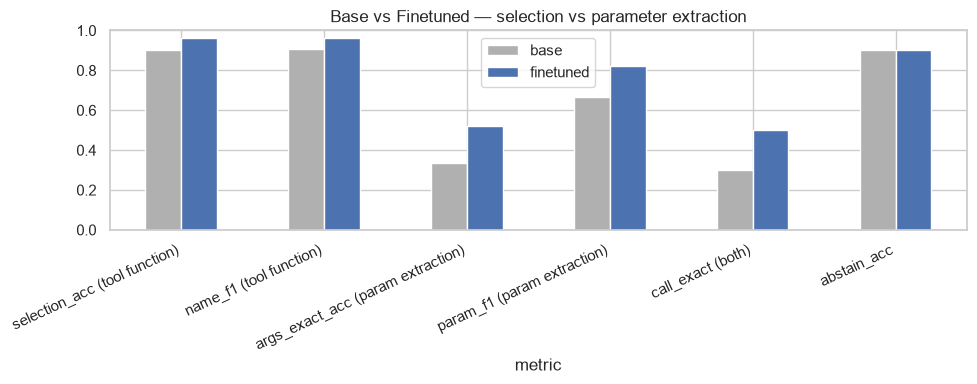

In [24]:
base_m = evaluate(test_eval, base_preds, family_of=family_of)
ft_m   = evaluate(test_eval, ft_preds,   family_of=family_of)

summary = pd.DataFrame({
    "metric": ["selection_acc (tool function)","name_f1 (tool function)",
               "args_exact_acc (param extraction)","param_f1 (param extraction)",
               "call_exact (both)","abstain_acc"],
    "base":      [base_m[k] for k in ["selection_acc","name_f1","args_exact_acc","param_f1","call_exact","abstain_acc"]],
    "finetuned": [ft_m[k]   for k in ["selection_acc","name_f1","args_exact_acc","param_f1","call_exact","abstain_acc"]],
})
summary["delta"] = (summary["finetuned"].astype(float) - summary["base"].astype(float)).round(3)
display(summary)

ax = summary.set_index("metric")[["base","finetuned"]].astype(float).plot.bar(
        figsize=(10,4), color=["#B0B0B0","#4C72B0"])
ax.set_title("Base vs Finetuned — selection vs parameter extraction"); ax.set_ylim(0,1)
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

### 6b · Per-tool and per-family breakdown

,name,n,selection_acc,args_exact_acc,param_f1,tool,total_params
2,wikipedia_search_wikipedia,10,0.9,0.2222,0.7407,wikipedia_search_wikipedia,2
0,pubmed_search_articles,10,1.0,0.8000,0.8824,pubmed_search_articles,3
4,semantic_scholar_search_papers,10,1.0,0.5000,0.8571,semantic_scholar_search_papers,3
3,google_web_search,10,1.0,0.3000,0.6875,google_web_search,4
1,arxiv_search_papers,10,0.9,0.7778,0.8947,arxiv_search_papers,6


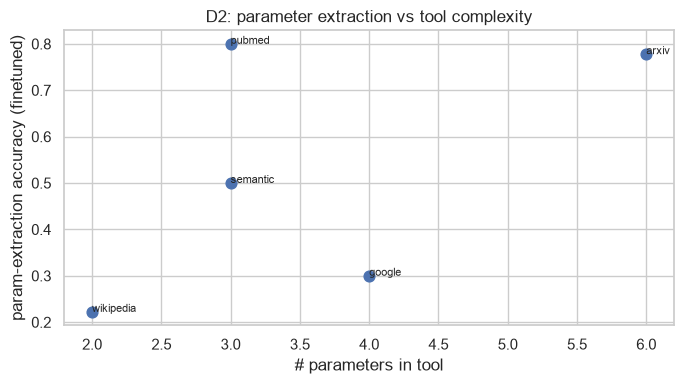

In [25]:
def per_frame(m, key):
    return pd.DataFrame([{ "name": k, "n": v["n"], "selection_acc": v["selection_acc"],
        "args_exact_acc": v["args_exact_acc"], "param_f1": v["param_f1"]} for k,v in m[key].items()])
pt = per_frame(ft_m,"per_tool").merge(cat.as_dataframe()[["tool","total_params"]],
                                      left_on="name", right_on="tool", how="left").sort_values("total_params")
display(pt)

plt.figure(figsize=(7,4))
plt.scatter(pt["total_params"], pt["args_exact_acc"], s=60, color="#4C72B0")
for _,r in pt.iterrows(): plt.annotate(r["name"].split("_")[0], (r["total_params"], r["args_exact_acc"]), fontsize=8)
plt.xlabel("# parameters in tool"); plt.ylabel("param-extraction accuracy (finetuned)")
plt.title("D2: parameter extraction vs tool complexity"); plt.tight_layout(); plt.show()

## 7 · D3 — disambiguation of similar tools

When PICKO picks the **wrong** tool, *which* tool does it pick? Confusions concentrate among
semantically similar tools (same category / same action across sources).

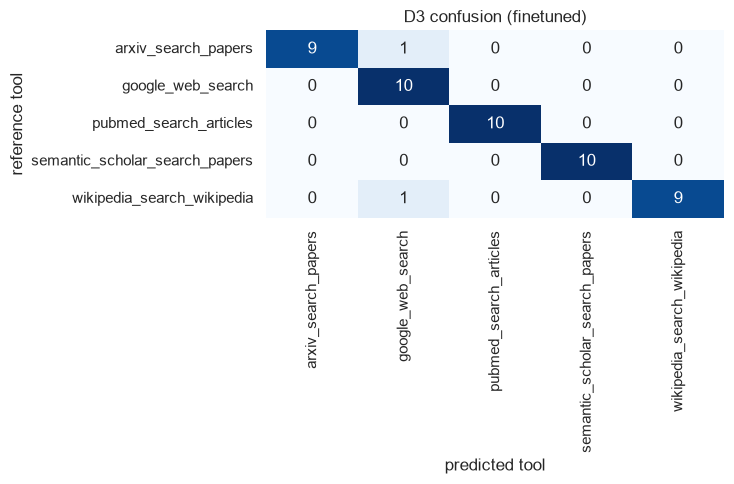

In [27]:
conf = confusion(test_eval, ft_preds)
labels = sorted(set(conf) | {p for row in conf.values() for p in row})
M = pd.DataFrame(0, index=sorted(conf), columns=labels)
for r, row in conf.items():
    for p, n in row.items(): M.loc[r, p] = n
plt.figure(figsize=(1.1*len(labels)+2, 0.6*len(M)+2))
if sns: sns.heatmap(M, annot=True, fmt="d", cmap="Blues", cbar=False)
else: plt.imshow(M.values, cmap="Blues"); plt.xticks(range(len(labels)),labels,rotation=90); plt.yticks(range(len(M)),M.index)
plt.xlabel("predicted tool"); plt.ylabel("reference tool"); plt.title("D3 confusion (finetuned)")
plt.tight_layout(); plt.show()

## 8 · D1 — tool-set size

**Cheap proxy (no retraining):** keep the finetuned model fixed and vary how many tools are *offered*
at eval time — the correct tool plus `k−1` distractors drawn from the **full 75-tool catalog**. Measure
tool-selection accuracy as `k` grows. Note: the model was finetuned offering only the `SUBSET` tools,
so growing `k` beyond `len(SUBSET)` deliberately pushes it out-of-distribution — that *is* the D1 stress
(how far one small model scales before the offered set should be sharded).

In [ ]:
ft_model, ft_params, _ = ft_bundle
Ks = [5, 10, 20, 50]
sel_by_k = []
for k in Ks:
    ov = build_tools_override(test_eval, k, cat.tools, seed=0)
    bar = tqdm(total=len(test_eval), desc=f"k={k}", unit="ex")
    preds_k = predict(ft_model, ft_params, tok, test_eval, tools_override=ov,
                      progress=lambda i,n: bar.update(i-bar.n))
    bar.close()
    sel_by_k.append(evaluate(test_eval, preds_k, family_of=family_of)["selection_acc"])
plt.figure(figsize=(7,4))
plt.plot(Ks, sel_by_k, "o-", color="#4C72B0", label="cheap (eval-time distractors)")
plt.xlabel("# tools offered (k)"); plt.ylabel("tool-selection accuracy")
plt.title("D1: does accuracy degrade as the tool set grows?"); plt.ylim(0,1); plt.legend(); plt.tight_layout(); plt.show()
pd.DataFrame({"k":Ks,"selection_acc":sel_by_k})

### 8b · D1 full retrain (optional, heavy)

The rigorous version: finetune a *separate* model for each tool-set size and evaluate. Many slow CPU
runs — gated behind `RUN_D1_FULL`. Overlay on the cheap curve to check the proxy.

In [ ]:
RUN_D1_FULL = False   # set True to retrain per size (very slow)
if RUN_D1_FULL:
    full = {}
    for k in Ks:
        names_k = SUBSET[:k] if k <= len(SUBSET) else [t["name"] for t in cat.tools[:k]]
        sub = cat.restrict_dataset(raw, names_k, seed=0)
        path = os.path.join(ROOT, "data", f"picko_d1_{k}.jsonl")
        with open(path, "w") as f:
            f.write("\n".join(json.dumps(e, ensure_ascii=False) for e in sub))
        subprocess.run(["needle","finetune",path,"--epochs",str(EPOCHS),"--batch-size",str(BATCH)], cwd=ROOT, check=True)
        ck = sorted(glob.glob(CKPT_GLOB), key=os.path.getmtime)[-1]
        mk, pk, tk = load_model(ck)
        _,_,tst = _per_tool_split(sub)
        pr = predict(mk, pk, tk, tst)
        full[k] = evaluate(tst, pr, family_of=family_of)["selection_acc"]
    print(full)
else:
    print("RUN_D1_FULL is False — skipping the heavy retrain sweep.")

## 9 · The research story

*(Fill in with your numbers as you run the cells. All figures above reflect the current `SUBSET` —
re-run 3a/3b with a different tool list to tell the story for another set.)*

**PICKO — a 26M tool-picker for scientific agents.** Needle already knows *which* tool a scientific
request needs (high `name_f1` even before finetuning) — the hard part is producing a **valid, correctly
parameterized call**. Finetuning on a few hundred examples per tool closes most of that gap:

- **D2 (parameter extraction):** the largest gains are here — `args_exact_acc` and `param_f1` jump,
  especially for multi-parameter tools (see §6b). This is where a small specialized model earns its keep.
- **D3 (disambiguation):** residual errors cluster among semantically similar tools (§7) — e.g. search
  tools that differ only by source. This is the frontier for a tool-picker and motivates confidence-based
  routing across categorical PICKO instances.
- **D1 (tool-set size):** selection accuracy vs `k` (§8) shows how far one small model scales before an
  orchestrator should shard the tool set.

**Takeaway:** for single-shot scientific tool calling, a tiny fine-tuned model is a strong, cheap
tool-picker — strongest on parameter extraction, with similar-tool disambiguation and large tool sets
as the open challenges.